# Notebook 06 - Experimento 2: Segmentación de resultados

## Objetivo
Analizar en que condiciones operativas funciona mejor o peor el modelo,
identificando donde se concentran los errores más grandes.

Este notebook **no entrena modelos**. Usa los mejores modelos del
Experimento 1 y analiza el error segmentado por distintos contextos.

## Dimensiones de segmentación

| Segmentación | Pregunta |
|---|---|
| Hora del día | ¿En qué horas falla más? |
| Régimen de irradiancia | ¿A qué nivel de irradiancia es más dificil predecir? |
| Tipo de rampa | ¿El error es mayor en subidas, bajadas o periodos estables? |
| Nivel de produccion | ¿A qué potencia relativa se cometen más errores? |

## Interpretacion esperada
- El modelo con *lag* presenta MAE sistematicamente inferior al sin *lag*
  en todos los contextos operativos.
- Los errores más grandes se concentran en irradiancia alta y en
  periodos de rampas bruscas.
- En transiciones rápidas los *lags* estabilizan la predicción pero
  no anticipan cambios bruscos.


### 1. Configuración de rutas e importaciones


In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"

from src.data import add_nominal_power_and_target, split_train_val_test
from src.evaluation import compute_metrics
from src.features import FeatureConfig, build_features, get_feature_columns

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga de modelos y metadatos del Experimento 1
Se leen los metadatos guardados por el notebook 05 para obtener los
nombres de los mejores modelos y sus listas de *features*.


In [2]:
metadata_path = MODELS_DIR / "best_models_metadata.json"
if not metadata_path.exists():
    raise FileNotFoundError(
        f"No se encontro {metadata_path.name}. "
        "Ejecuta primero el notebook 05."
    )

with open(metadata_path, encoding="utf-8") as f:
    metadata = json.load(f)

best_lag_name   = metadata["best_with_lag"]
best_nolag_name = metadata["best_without_lag"]
feat_lag        = metadata["features_with_lag"]
feat_nolag      = metadata["features_without_lag"]

lag_path   = MODELS_DIR / f"best_with_lag_{best_lag_name.replace(' ', '_')}.joblib"
nolag_path = MODELS_DIR / f"best_without_lag_{best_nolag_name.replace(' ', '_')}.joblib"

best_lag_model   = joblib.load(lag_path)
best_nolag_model = joblib.load(nolag_path)

print(f"Modelo con lag:  {best_lag_name}")
print(f"Modelo sin lag:  {best_nolag_name}")
print(f"Features con lag: {len(feat_lag)} | sin lag: {len(feat_nolag)}")


Modelo con lag:  MLP
Modelo sin lag:  Ridge
Features con lag: 32 | sin lag: 19


### 3. Reconstrucción del conjunto de test
Se regenera el *dataset* de test con ambas configuraciones de *features*
para obtener las predicciones sobre el índice común.


In [3]:
df_all = pd.read_csv(DATA_DIR / "df_all_unificado.csv", parse_dates=["timestamp"])

NOMINAL_POWER = {"E03": 12.4, "Afrisol": 12.0, "LECA1": 19.53}
df_all = df_all.drop(columns=["power_pu", "p_nominal_kw"], errors="ignore")
df_all = add_nominal_power_and_target(df_all, NOMINAL_POWER)

config_lag = FeatureConfig(
    lag_steps_power=(1, 2, 4), lag_steps_radiation=(1, 2),
    rolling_windows_power=(4, 8), rolling_windows_radiation=(4,),
    add_interactions=True, add_daylight_flag=True,
    drop_na_after_features=True, one_hot_encode_plant=False,
)
config_nolag = FeatureConfig(
    lag_steps_power=(), lag_steps_radiation=(),
    rolling_windows_power=(), rolling_windows_radiation=(),
    add_interactions=True, add_daylight_flag=True,
    drop_na_after_features=True, one_hot_encode_plant=False,
)

def build_test(df: pd.DataFrame, config: FeatureConfig):
    """Construye el dataset de test aplicando el pipeline de features."""
    df_feat = build_features(df, config=config).drop(columns=["Mes"], errors="ignore")
    _, _, test_df = split_train_val_test(
        df_feat,
        train_plants=["Afrisol", "E03"],
        test_plant="LECA1",
    )
    return test_df, get_feature_columns(df_feat)

test_lag,   _ = build_test(df_all, config_lag)
test_nolag, _ = build_test(df_all, config_nolag)

common_idx = test_lag.index.intersection(test_nolag.index)

test_seg = test_lag.loc[common_idx].copy()
test_seg["y_pred_lag"]   = best_lag_model.predict(test_lag.loc[common_idx, feat_lag])
test_seg["y_pred_nolag"] = best_nolag_model.predict(test_nolag.loc[common_idx, feat_nolag])
test_seg["error_lag"]    = (test_seg["power_pu"] - test_seg["y_pred_lag"]).abs()
test_seg["error_nolag"]  = (test_seg["power_pu"] - test_seg["y_pred_nolag"]).abs()
test_seg["error_rel_lag"]   = test_seg["error_lag"]   / (test_seg["power_pu"] + 1e-6)
test_seg["error_rel_nolag"] = test_seg["error_nolag"] / (test_seg["power_pu"] + 1e-6)

print(f"Test segmentado: {len(test_seg)} filas")


2026-05-27 10:55:18 - INFO - Split: train=138986 | val=11330 | test=8639
2026-05-27 10:55:21 - INFO - Split: train=138994 | val=11330 | test=8639


Test segmentado: 8627 filas


### 4. Segmentación por hora del día
MAE absoluto y relativo por hora, restringido a horas de producción
(`power_pu > 0`) para evitar el sesgo nocturno.


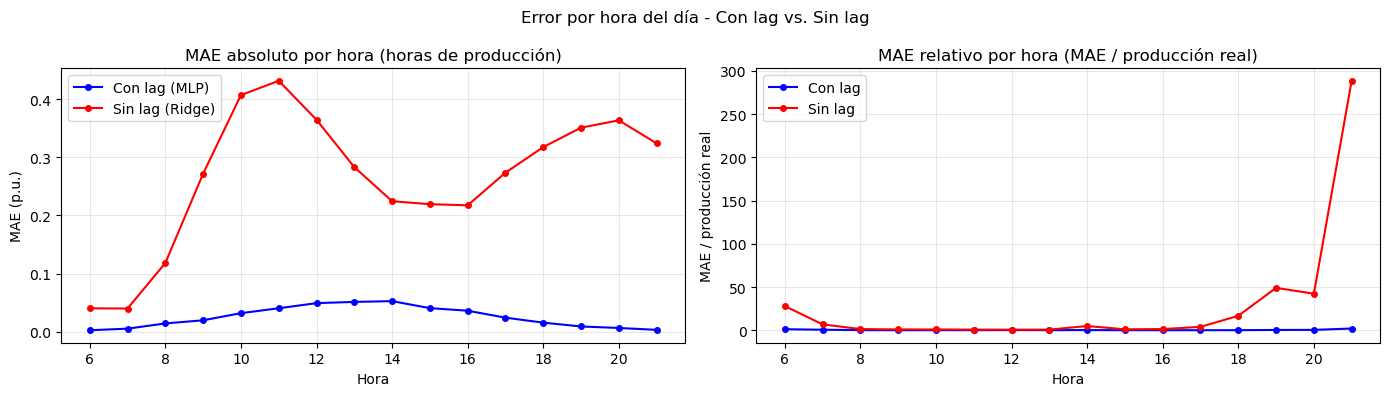

In [4]:
test_day = test_seg[test_seg["power_pu"] > 0].copy()

hourly = test_day.groupby("hour").agg(
    MAE_lag=(   "error_lag",    "mean"),
    MAE_nolag=( "error_nolag",  "mean"),
    MAE_rel_lag=(  "error_rel_lag",  "mean"),
    MAE_rel_nolag=("error_rel_nolag", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hourly["hour"], hourly["MAE_lag"],
             "b-o", ms=4, label=f"Con lag ({best_lag_name})")
axes[0].plot(hourly["hour"], hourly["MAE_nolag"],
             "r-o", ms=4, label=f"Sin lag ({best_nolag_name})")
axes[0].set_title("MAE absoluto por hora (horas de producción)")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("MAE (p.u.)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hourly["hour"], hourly["MAE_rel_lag"],
             "b-o", ms=4, label="Con lag")
axes[1].plot(hourly["hour"], hourly["MAE_rel_nolag"],
             "r-o", ms=4, label="Sin lag")
axes[1].set_title("MAE relativo por hora (MAE / producción real)")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("MAE / producción real")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Error por hora del día - Con lag vs. Sin lag", fontsize=12)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "segm_error_hora.png", dpi=150)
plt.show()


### 5. Segmentación por nivel de irradiancia


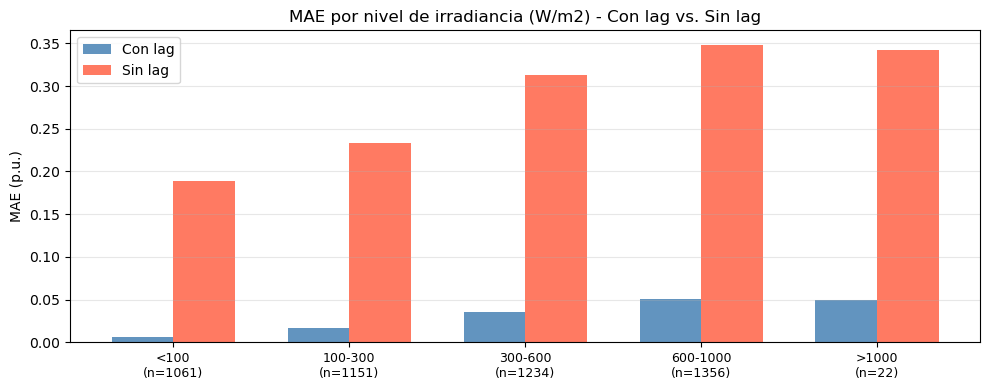

,rad_bin,MAE_lag,MAE_nolag,n
0,<100,0.006686,0.188598,1061
1,100-300,0.016956,0.233466,1151
2,300-600,0.035113,0.313311,1234
3,600-1000,0.050748,0.347874,1356
4,>1000,0.050028,0.342745,22


In [5]:
bins_rad   = [0, 100, 300, 600, 1000, 2000]
labels_rad = ["<100", "100-300", "300-600", "600-1000", ">1000"]

test_day = test_day.copy()
test_day["rad_bin"] = pd.cut(
    test_day["radiation"], bins=bins_rad, labels=labels_rad
)

rad_seg = test_day.groupby("rad_bin", observed=True).agg(
    MAE_lag=(  "error_lag",   "mean"),
    MAE_nolag=("error_nolag", "mean"),
    n=(        "power_pu",    "count"),
).reset_index()

x = range(len(rad_seg))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - w/2 for i in x], rad_seg["MAE_lag"],
       width=w, label="Con lag",  color="steelblue", alpha=0.85)
ax.bar([i + w/2 for i in x], rad_seg["MAE_nolag"],
       width=w, label="Sin lag",  color="tomato",    alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{l}\n(n={n})" for l, n in zip(rad_seg["rad_bin"], rad_seg["n"])],
    fontsize=9,
)
ax.set_title("MAE por nivel de irradiancia (W/m2) - Con lag vs. Sin lag")
ax.set_ylabel("MAE (p.u.)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "segm_error_irradiancia.png", dpi=150)
plt.show()

display(rad_seg.round(6))


### 6. Segmentación por tipo de rampa
Una rampa se define como un cambio de producción superior a 0.05 p.u.
entre dos intervalos consecutivos de 15 minutos (~1 kW en LECA1).


Error por tipo de rampa:


,ramp_type,MAE_lag,MAE_nolag,n
0,Bajada,0.0380,0.2715,886
1,Estable,0.0202,0.2596,2974
2,Subida,0.0477,0.3341,964


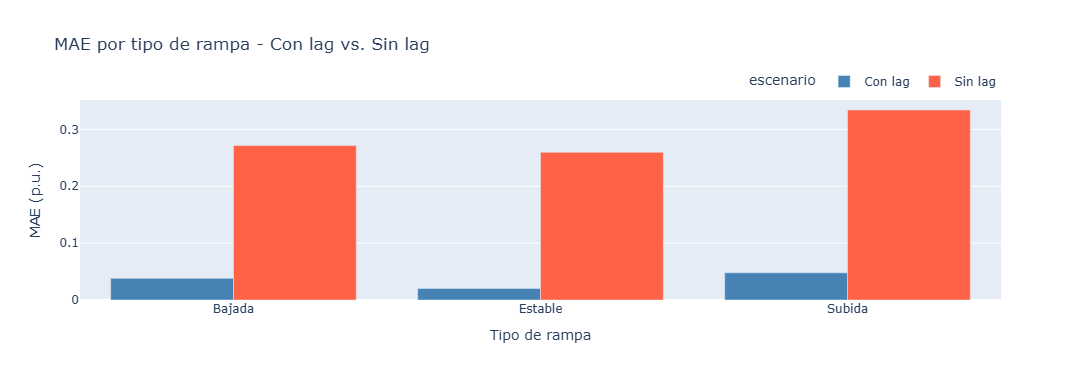

In [8]:
RAMP_THRESHOLD = 0.05  # p.u. (~1 kW en LECA1)

test_day = test_day.sort_values("timestamp").copy()
test_day["delta_power"] = test_day["power_pu"].diff()

test_day["ramp_type"] = "Estable"
test_day.loc[test_day["delta_power"] >  RAMP_THRESHOLD, "ramp_type"] = "Subida"
test_day.loc[test_day["delta_power"] < -RAMP_THRESHOLD, "ramp_type"] = "Bajada"

ramp_seg = test_day.groupby("ramp_type").agg(
    MAE_lag=(  "error_lag",   "mean"),
    MAE_nolag=("error_nolag", "mean"),
    n=(        "power_pu",    "count"),
).reset_index()

print("Error por tipo de rampa:")
display(ramp_seg.round(4))

ramp_melted = ramp_seg.melt(
    id_vars=["ramp_type", "n"],
    value_vars=["MAE_lag", "MAE_nolag"],
    var_name="escenario", value_name="MAE",
)
ramp_melted["escenario"] = ramp_melted["escenario"].map(
    {"MAE_lag": "Con lag", "MAE_nolag": "Sin lag"}
)

fig = px.bar(
    ramp_melted, x="ramp_type", y="MAE", color="escenario",
    barmode="group",
    title="MAE por tipo de rampa - Con lag vs. Sin lag",
    labels={"MAE": "MAE (p.u.)", "ramp_type": "Tipo de rampa"},
    color_discrete_map={"Con lag": "steelblue", "Sin lag": "tomato"},
)
fig.update_layout(height=380,
            legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
                 )

fig.show()


### 7. Segmentación por nivel de producción
Se divide la produccion normalizada en seis intervalos para analizar
si el error es sistematicamente mayor en producción baja o alta.


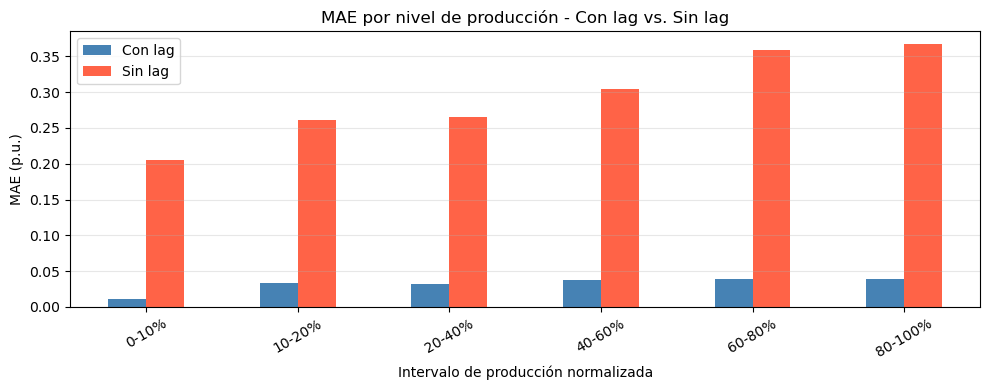

,prod_bin,MAE_lag,MAE_nolag
0,0-10%,0.011063,0.205071
1,10-20%,0.032822,0.260790
2,20-40%,0.032382,0.265465
3,40-60%,0.037615,0.305024
4,60-80%,0.038750,0.358725
5,80-100%,0.039230,0.366576


In [7]:
test_day["prod_bin"] = pd.cut(
    test_day["power_pu"],
    bins=[0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0-10%", "10-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
)

prod_seg = test_day.groupby("prod_bin", observed=True).agg(
    MAE_lag=(  "error_lag",   "mean"),
    MAE_nolag=("error_nolag", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
prod_seg.plot(
    x="prod_bin", y=["MAE_lag", "MAE_nolag"],
    kind="bar", ax=ax,
    color=["steelblue", "tomato"],
    label=["Con lag", "Sin lag"],
)
ax.set_title("MAE por nivel de producción - Con lag vs. Sin lag")
ax.set_xlabel("Intervalo de producción normalizada")
ax.set_ylabel("MAE (p.u.)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.grid(alpha=0.3, axis="y")
ax.legend(["Con lag", "Sin lag"])
plt.tight_layout()
plt.savefig(RESULTS_DIR / "segm_error_produccion.png", dpi=150)
plt.show()

display(prod_seg.round(6))


## Conclusiones del Experimento 2

**Por hora del día:**
- El error máximo se produce entre las 11:00 y las 14:00, coincidiendo
  con las horas de mayor irradiancia y producción.
- El modelo con *lag* mantiene MAE inferior al sin *lag* en todas las horas.
- En terminos relativos (MAE/producción), el error es mayor en las
  horas de producción baja (rampas de mañana y tarde).

**Por nivel de irradiancia:**
- La mejora de los *lags* es mayor en irradiancia media-alta (300-1000 W/m2).
- En irradiancia muy baja (<100 W/m2) ambos modelos cometen errores similares,
  ya que la producción es casi nula.
- En irradiancia alta el modelo sin *lag* falla notablemente, confirmando
  que la memoria temporal es crítica en condiciones de plena producción.

**Por tipo de rampa:**
- Los *lags* reducen el error tanto en periodos estables como en rampas.
- En transiciones rápidas (subidas/bajadas > 5% en 15 min) la mejora
  es más limitada: los *lags* estabilizan, pero no anticipan cambios bruscos.

**Por nivel de producción:**
- La dispersión es mayor en producción baja (amanecer/atardecer)
  para ambos modelos.
- El modelo con lag reduce el error en todos los rangos de producción.
- Los modelos tienden a subestimar los picos de producción (>80% p.u.).

**Archivos de salida:**
- `data/results/segm_error_hora.png`
- `data/results/segm_error_irradiancia.png`
- `data/results/segm_error_produccion.png`

**Siguiente paso:** Experimento 3 - análisis de horizonte de predicción múltiple.
